# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "cfc12"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[249.16 250.9176 252.6752 ... 286.7556666666667 290.483 290.483] [249.16 250.9176 252.6752 ... 283.06 290.483 290.483] [249.16 250.91760000000002 253.56207142857141 ... 283.06 290.483 290.483] [249.16 252.8435681818182 256.5271363636364 ... 283.06 290.483 290.483] [249.16 250.91760000000002 255.64816666666667 ... 283.8078863636364 290.483 290.483] [249.16 250.9176 252.6752 ... 285.3036590909091 290.483 290.483]] [[250.774 252.3578 253.9416 ... 286.01800000000003 288.151 288.151] [250.774 252.3578 253.9416 ... 284.17350000000005 288.151 288.151] [250.77399999999997 252.35780000000003 255.13814285714287 ... 284.17350000000005 288.151 288.151] [250.774 254.479 258.184 ... 284.17350000000005 288.151 288.151] [250.774 252.35780000000003 257.2568333333333 ... 284.228 288.151 288.151] [250.774 252.3578 253.9416 ... 284.337 288.151 288.151]] [[252.348 253.63280000000003 254.9176 ... 285.7713333333333 287.005 287.005] [252.348 253.6328 254.9176 ... 286.64799999999997 287.005 287.005] [252.348 253.63280000000003 256.6079285714286 ... 286.648 287.005 287.005] [252.348 256.2376136363637 260.1272272727273 ... 286.648 287.005 287.005] [252.348 253.6328 258.57800000000003 ... 285.94147727272724 287.005 287.005] [252.348 253.6328 254.9176 ... 284.52843181818184 287.005 287.005]] ... [[483.22 484.23290000000003 484.3845 ... 483.2185 483.135 483.184] [483.22 484.52 484.36828571428566 ... 483.36666666666673 483.2753333333333 483.184] [483.21999999999997 483.8312941176471 483.7538823529412 ... 483.212 483.275 483.184] [483.22 483.26823809523813 483.3164761904762 ... 483.39414285714287 483.23999999999995 483.184] [483.21999999999997 483.6587 483.7586190476191 ... 483.35914285714284 483.205 483.184] [483.22 483.9458 484.09740000000005 ... 483.3241428571428 483.17 483.184]] [[483.37 483.37 483.741 ... 483.101 483.063 483.243] [483.37 483.37 483.3635714285714 ... 483.29766666666666 483.2703333333333 483.243] [483.37 483.37 483.51786666666663 ... 482.991 484.05 483.243] [483.37 483.37 483.741 ... 483.9178571428572 483.80325 483.243] [483.37 483.37 483.741 ... 483.6711071428572 483.5565 483.243] [483.37 483.37 483.74100000000004 ... 483.42435714285716 483.30974999999995 483.243]] [[482.91 482.91 483.0685 ... 483.17150000000004 483.333 483.779] [482.91 482.91 482.9577142857143 ... 483.42233333333337 483.60066666666665 483.779] [482.91 482.91 482.98716666666667 ... 482.958 483.21 483.779] [482.91 482.91 483.0685 ... 483.23 483.24075 483.779] [482.91 482.91 483.06850000000003 ... 483.26075000000003 483.2715 483.779] [482.91 482.91 483.06850000000003 ... 483.2915 483.30225 483.779]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[249.16 250.9176 252.6752 ... 286.7556666666667 290.483 290.483] [249.16 250.9176 252.6752 ... 283.06 290.483 290.483] [249.16 250.91760000000002 253.56207142857141 ... 283.06 290.483 290.483] [249.16 252.8435681818182 256.5271363636364 ... 283.06 290.483 290.483] [249.16 250.91760000000002 255.64816666666667 ... 283.8078863636364 290.483 290.483] [249.16 250.9176 252.6752 ... 285.3036590909091 290.483 290.483]] [[250.774 252.3578 253.9416 ... 286.01800000000003 288.151 288.151] [250.774 252.3578 253.9416 ... 284.17350000000005 288.151 288.151] [250.77399999999997 252.35780000000003 255.13814285714287 ... 284.17350000000005 288.151 288.151] [250.774 254.479 258.184 ... 284.17350000000005 288.151 288.151] [250.774 252.35780000000003 257.2568333333333 ... 284.228 288.151 288.151] [250.774 252.3578 253.9416 ... 284.337 288.151 288.151]] [[252.348 253.63280000000003 254.9176 ... 285.7713333333333 287.005 287.005] [252.348 253.6328 254.9176 ... 286.64799999999997 287.005 287.005] [252.348 253.63280000000003 256.6079285714286 ... 286.648 287.005 287.005] [252.348 256.2376136363637 260.1272272727273 ... 286.648 287.005 287.005] [252.348 253.6328 258.57800000000003 ... 285.94147727272724 287.005 287.005] [252.348 253.6328 254.9176 ... 284.52843181818184 287.005 287.005]] ... [[483.22 484.23290000000003 484.3845 ... 483.2185 483.135 483.184] [483.22 484.52 484.36828571428566 ... 483.36666666666673 483.2753333333333 483.184] [483.21999999999997 483.8312941176471 483.7538823529412 ... 483.212 483.275 483.184] [483.22 483.26823809523813 483.3164761904762 ... 483.39414285714287 483.23999999999995 483.184] [483.21999999999997 483.6587 483.7586190476191 ... 483.35914285714284 483.205 483.184] [483.22 483.9458 484.09740000000005 ... 483.3241428571428 483.17 483.184]] [[483.37 483.37 483.741 ... 483.101 483.063 483.243] [483.37 483.37 483.3635714285714 ... 483.29766666666666 483.2703333333333 483.243] [483.37 483.37 483.51786666666663 ... 482.991 484.05 483.243] [483.37 483.37 483.741 ... 483.9178571428572 483.80325 483.243] [483.37 483.37 483.741 ... 483.6711071428572 483.5565 483.243] [483.37 483.37 483.74100000000004 ... 483.42435714285716 483.30974999999995 483.243]] [[482.91 482.91 483.0685 ... 483.17150000000004 483.333 483.779] [482.91 482.91 482.9577142857143 ... 483.42233333333337 483.60066666666665 483.779] [482.91 482.91 482.98716666666667 ... 482.958 483.21 483.779] [482.91 482.91 483.0685 ... 483.23 483.24075 483.779] [482.91 482.91 483.06850000000003 ... 483.26075000000003 483.2715 483.779] [482.91 482.91 483.06850000000003 ... 483.2915 483.30225 483.779]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'cfc12' (lon: 6, lat: 12, year: 45, month: 12)> Size: 311kB
<Quantity([[[[261.187      262.461      263.714      ... 279.452
    282.092      282.914     ]
   [281.977      280.853      281.578      ... 296.289
    294.531      293.141     ]
   [294.251      296.954      299.33       ... 309.491
    310.936      312.395     ]
   ...
   [495.264      494.351      493.755      ... 491.954
    491.704      491.595     ]
   [491.302      490.987      490.807      ... 488.669
    488.269      488.045     ]
   [487.63       487.458      487.078      ... 484.61
    484.137      483.687     ]]

  [[263.092      264.4338     265.5168     ... 280.1094
    282.4224     283.1024    ]
   [282.395      281.847      283.079      ... 295.3728
    294.3106     293.6764    ]
   [295.1396     297.866      300.2824     ... 310.4886
    312.1634     313.9724    ]
...
   [496.74133333 496.80658333 496.73558333 ... 492.98391667
    493.09591667 493.16525   ]
   [492.90558333 492.68791667 492.60041667 ... 487.84075
    489.49041667 489.0775    ]
   [489.08991667 488.88205556 488.71644444 ... 484.48483333
    484.51155556 484.62677778]]

  [[296.358      296.207      296.741      ... 305.716
    308.472      309.65      ]
   [309.785      310.123      311.233      ... 321.553
    325.417      326.322     ]
   [325.925      326.163      328.086      ... 339.188
    340.938      343.883     ]
   ...
   [497.758      497.6235     497.3835     ... 494.205
    494.1485     493.9425    ]
   [493.3715     493.3145     493.47       ... 487.974
    490.244      489.7085    ]
   [489.7925     489.722      489.387      ... 484.899
    484.8705     485.12      ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 360B 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[261.187 262.461 263.714 ... 484.61 484.137 483.687] [263.09200000000004 264.4338 265.5168 ... 485.31035 484.7317 484.7799] [264.997 266.4066 267.3196 ... 485.78375000000005 485.4005000000001 485.3025] ... [294.92033333333336 294.39033333333333 294.26733333333334 ... 484.428 484.4445 484.31725] [296.358 296.207 296.741 ... 483.255 483.303 483.368] [296.358 296.207 296.741 ... 484.36150000000004 484.22275 484.338]] [[261.187 262.461 263.714 ... 484.61 484.137 483.687] [263.09200000000004 264.4338 265.5168 ... 485.38599999999997 484.70699999999994 484.96999999999997] [264.997 266.4066 267.3196 ... 485.2 484.61814285714286 484.8042857142857] ... [290.42999999999995 291.3539999999999 293.49449999999996 ... 483.99733333333336 483.91499999999996 483.7253333333333] [296.358 296.207 296.741 ... 483.9106666666667 483.745 483.6406666666667] [296.358 296.207 296.741 ... 483.824 483.575 483.556]] [[261.187 262.461 263.714 ... 484.61 484.137 483.68699999999995] [263.09200000000004 264.4338 265.51680000000005 ... 485.26572727272725 484.72999999999996 484.6267272727273] [265.57378571428575 266.99642857142857 268.1847142857143 ... 485.8011818181819 485.346 485.22318181818184] ... [290.43 291.35400000000004 293.4945 ... 485.187 485.279 485.3035] [296.358 296.207 296.741 ... 483.702 483.789 483.925] [296.358 296.207 296.741 ... 484.899 484.8705 485.12]] [[261.187 262.461 263.714 ... 484.61 484.137 483.687] [264.37534090909094 265.634 267.02436363636366 ... 485.09831249999996 484.69562499999995 484.3245625] [267.5636818181818 268.807 270.33472727272726 ... 485.58662499999997 485.25425 484.962125] ... [290.43 291.354 293.4945 ... 487.915 487.6913333333334 487.6046666666666] [296.358 296.207 296.741 ... 486.9445 486.9286666666667 487.1443333333333] [296.358 296.207 296.741 ... 485.974 486.166 486.684]] [[261.187 262.461 263.714 ... 484.61 484.137 483.68699999999995] [263.09200000000004 264.4338 265.51680000000005 ... 485.15905000000004 484.78110000000004 484.3997] [267.9175 268.821 269.484 ... 485.63990625 485.39481250000006 484.97978125000003] ... [290.97793181818184 291.69 293.48172727272726 ... 486.75266666666664 486.6090555555555 486.508861111111] [296.358 296.207 296.741 ... 485.7146666666667 485.7201111111111 485.8855555555556] [296.358 296.207 296.741 ... 485.4365 485.51824999999997 485.90200000000004]] [[261.187 262.461 263.714 ... 484.61 484.137 483.687] [263.09200000000004 264.4338 265.5168 ... 485.23470000000003 484.75640000000004 484.5898] [264.997 266.4066 267.31960000000004 ... 485.7081 485.4252 485.1124] ... [292.07379545454546 292.362 293.4561818181818 ... 485.5903333333334 485.5267777777778 485.4130555555555] [296.358 296.207 296.741 ... 484.4848333333333 484.51155555555556 484.62677777777776] [296.358 296.207 296.741 ... 484.899 484.8705 485.12]]]
Units,ppt


### Longitudinal-mean

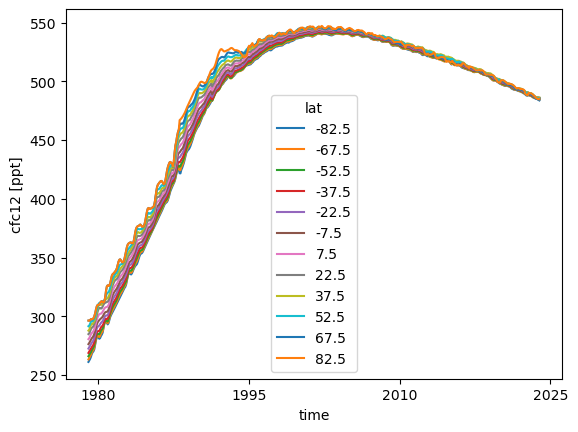

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

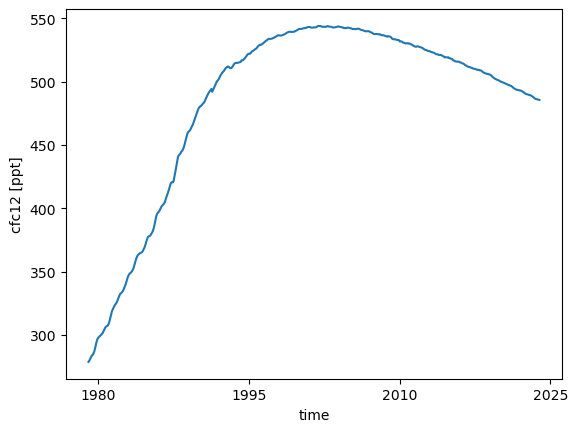

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

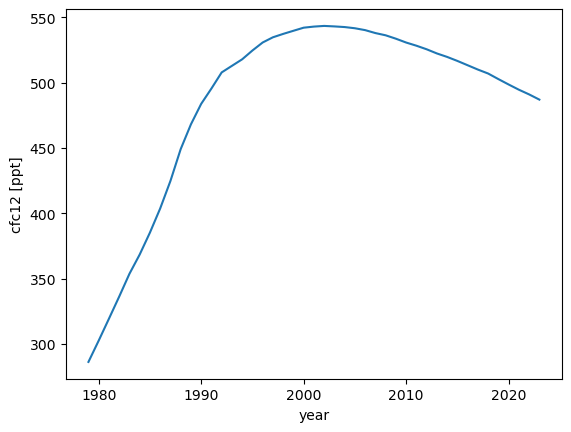

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 6kB
Dimensions:               (lat: 12, eof: 12, year: 45)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 360B 1979 1980 1981 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3921 0.4093 ... 0.05329
    principal-components  (year, eof) float64 4kB [] -36.8 -2.253 ... 1.677e-14

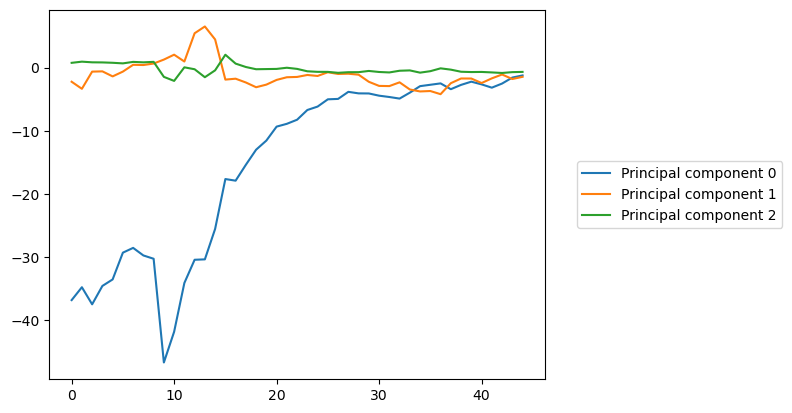

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

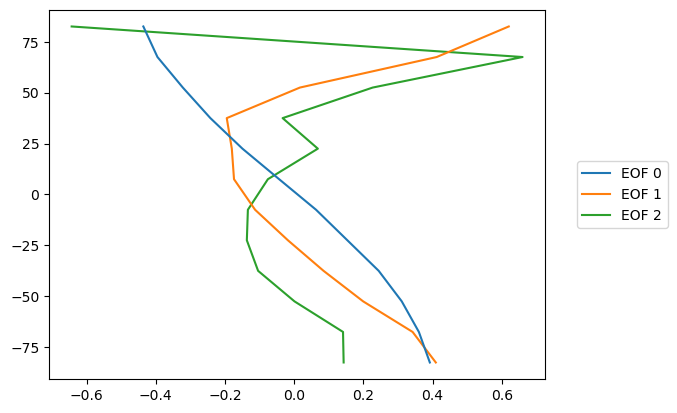

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

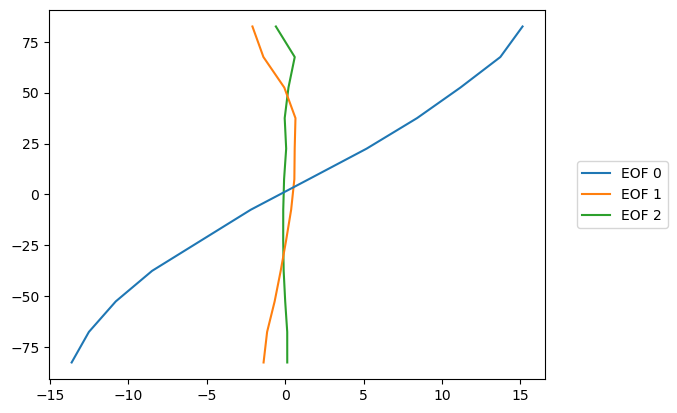

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.3920596252904669] [0.36040761684462164] [0.31100397745040187] [0.24432370939146847] [0.15379250427783914] [0.0632506860745019] [-0.0433748163497534] [-0.14944289238283928] [-0.24210768373031868] [-0.3217081603669011] [-0.39504232592312943] [-0.43582106913269286]]
Units,ppt
Magnitude,[[-36.79740572521904] [-34.76109035350583] [-37.46473421282341] [-34.55726886190566] [-33.527038893392145] [-29.29134492223208] [-28.53708968448413] [-29.732731325862062] [-30.257076152936285] [-46.66511908354876] [-41.808327547268476] [-34.087416201740304] [-30.41610370100025] [-30.352608729614655] [-25.539620632869728] [-17.6457070047959] [-17.903811894959297] [-15.39151676348094] [-13.003928246388499] [-11.561243792702147] [-9.35257139590249] [-8.909033050703247] [-8.261064848113888] [-6.7230417459833625] [-6.181889844796694] [-5.0331575008587] [-4.967903910387246] [-3.8506103741900866] [-4.092235947137482] [-4.1053596626096605] [-4.4565230098401] [-4.666227247335961] [-4.917221110058246] [-3.981506557723386] [-2.950036367370497] [-2.7313776869654034] [-2.513101477057137] [-3.4314993087469627] [-2.7490877003280043] [-2.2414200553510173] [-2.6668721592102407] [-3.1900899580988438] [-2.540767827013856] [-1.591180541912646] [-1.2552212198547883]]
Units,dimensionless


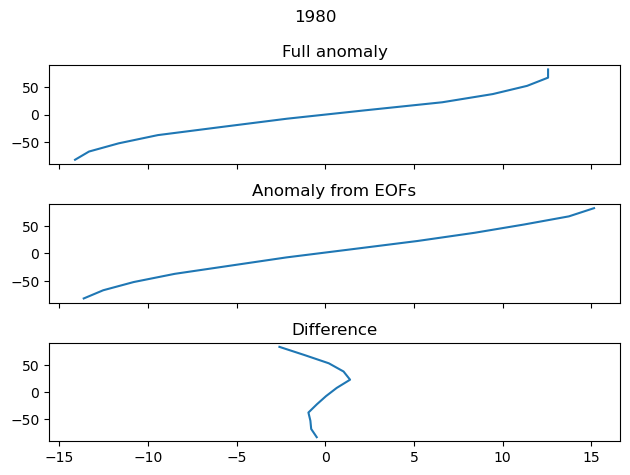

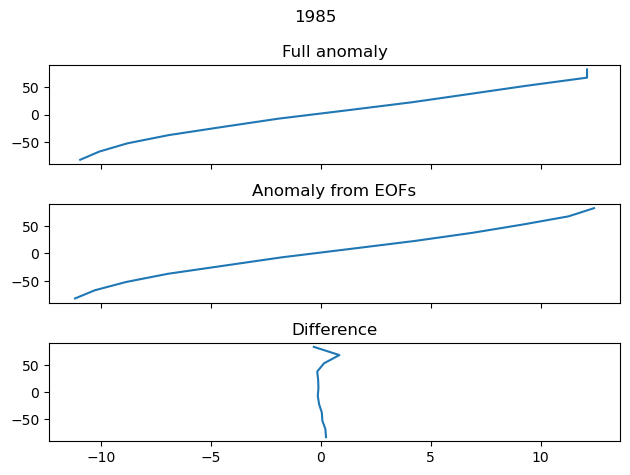

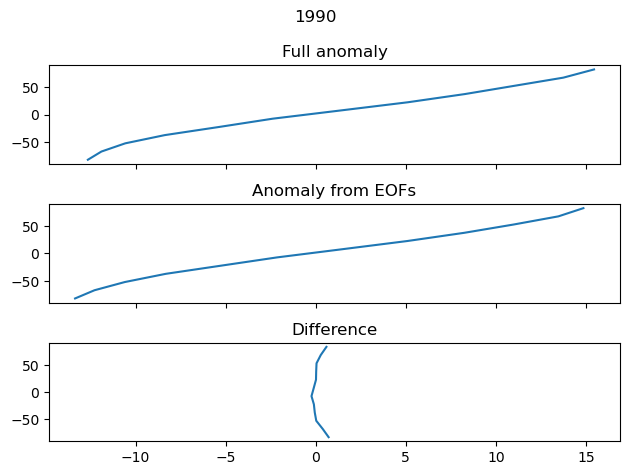

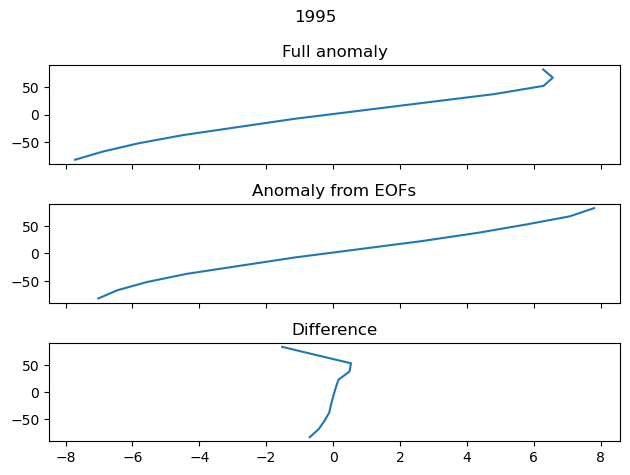

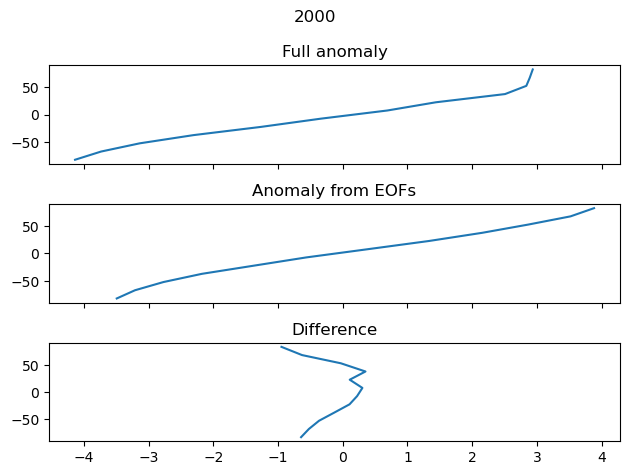

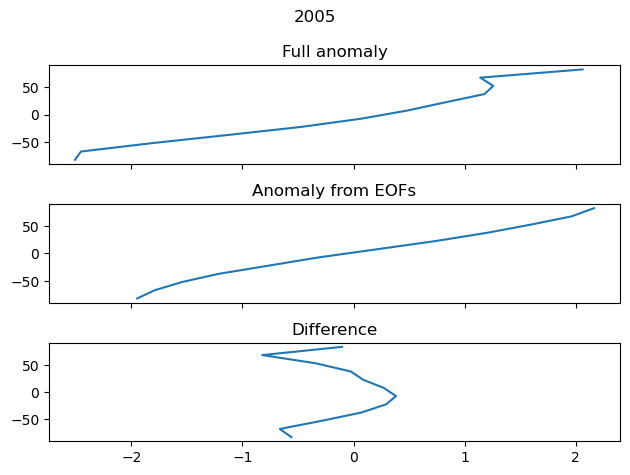

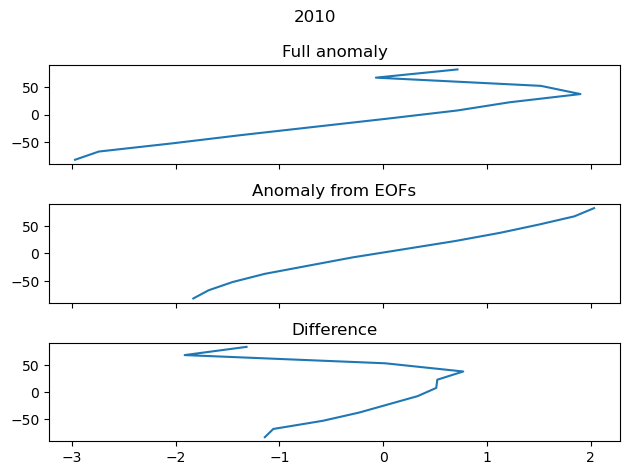

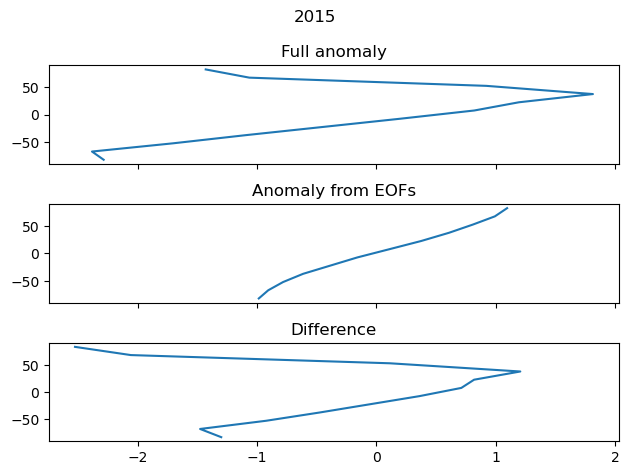

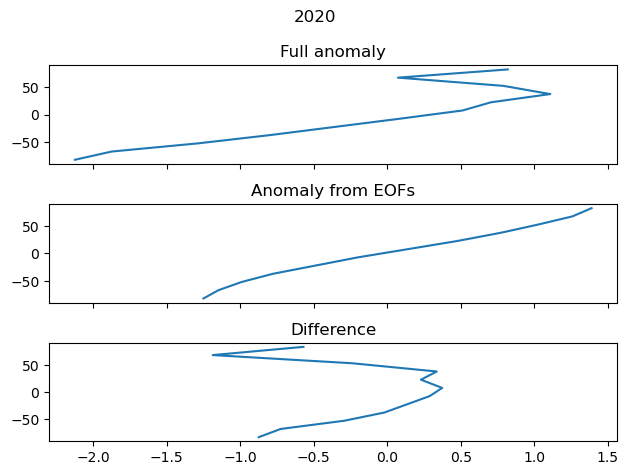

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/540 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 540/540 [00:00<00:00, 18819.79it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/540 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/540 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 540/540 [00:00<00:00, 19582.27it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/540 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 540/540 [00:00<00:00, 19719.69it/s]

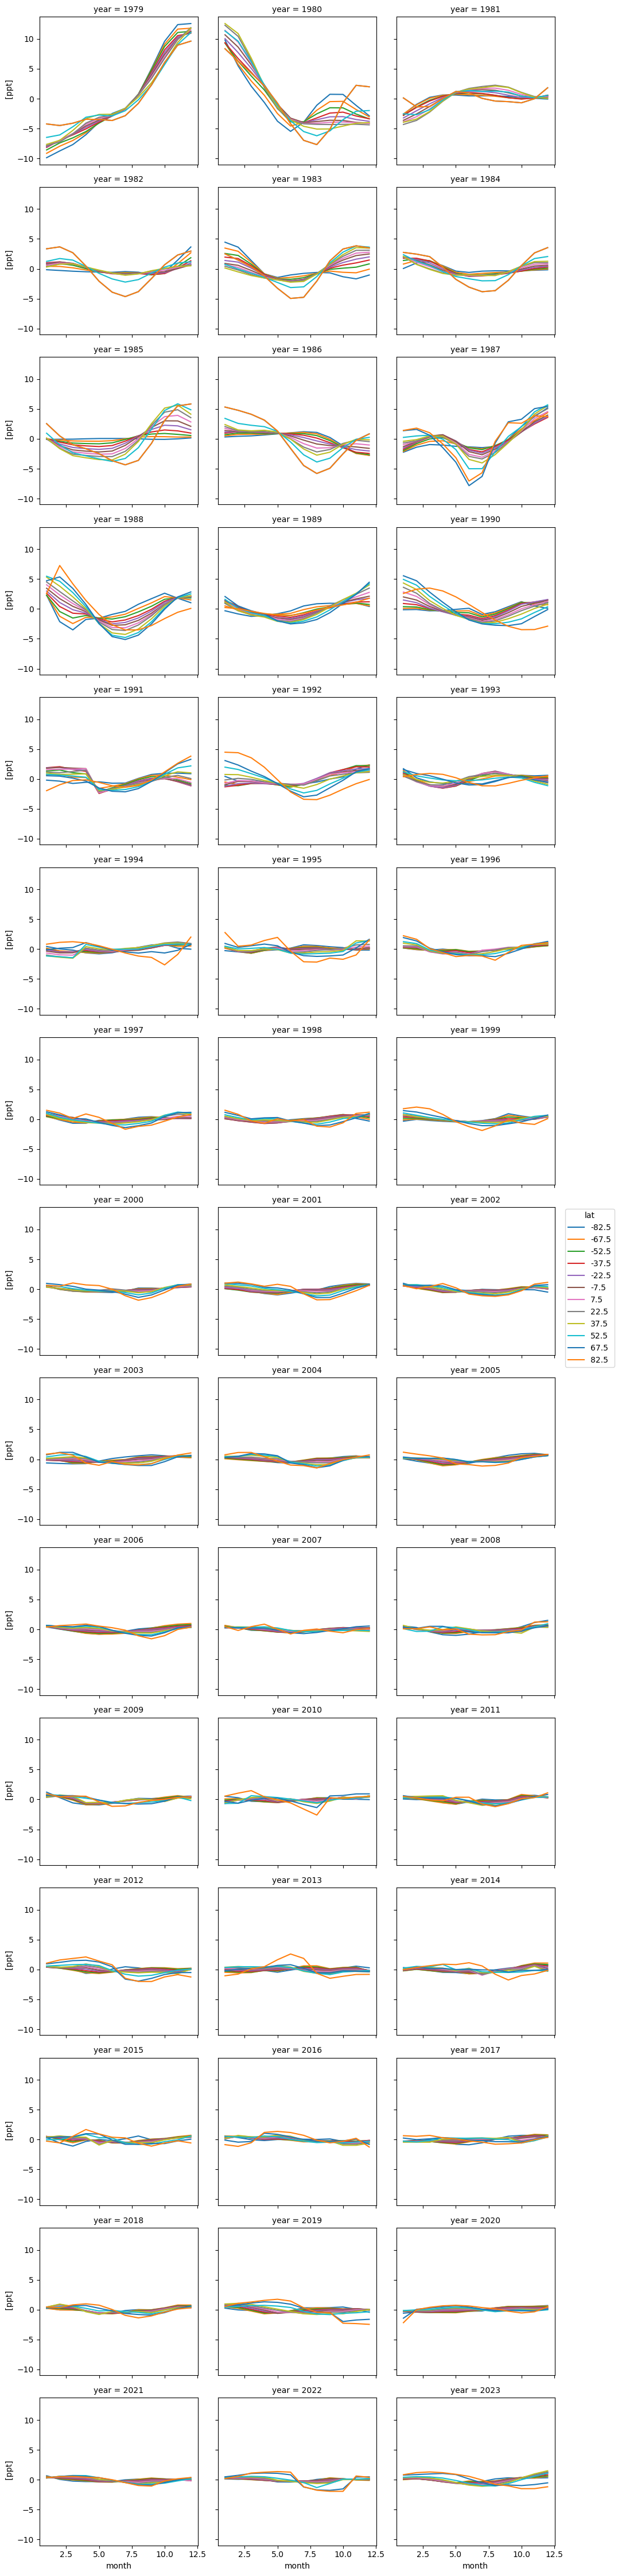

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

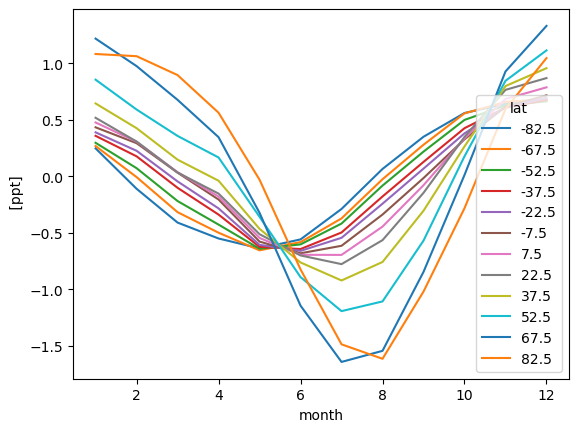

In [22]:
seasonality.plot.line(hue="lat")

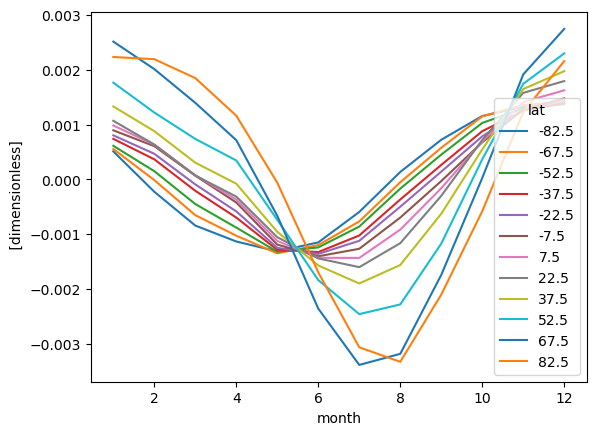

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[286.3356965563874 302.63791125997875 319.4089368952329 336.32682642943735 353.77526239000434 368.5255205074763 385.31860226826774 403.78329689958855 424.82940651793024 449.18159871574534 468.1724309424256 483.82934967605934 495.5740036138909 507.90256653018656 512.9300341596797 517.9345758089925 524.6647035485565 530.8016394709261 534.7838096647987 537.3763864390276 539.7663001131684 542.1326106580592 542.9720817924772 543.4859408339802 543.1072910611365 542.6180829346767 541.6995366974694 540.265227656714 538.0185224270668 536.30943801493 533.7058146600824 530.7726545766368 528.3504944710462 525.6105650992196 522.4217666452986 519.7627643243678 516.6971678577962 513.395194820453 510.085667614866 507.05820712896093 502.79386669497006 498.6626753313642 494.6675318433342 491.07463339130385 487.08898688712264]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.3920596252904669] [0.36040761684462164] [0.31100397745040187] [0.24432370939146847] [0.15379250427783914] [0.0632506860745019] [-0.0433748163497534] [-0.14944289238283928] [-0.24210768373031868] [-0.3217081603669011] [-0.39504232592312943] [-0.43582106913269286]]
Units,ppt
Magnitude,[[-36.79740572521904] [-34.76109035350583] [-37.46473421282341] [-34.55726886190566] [-33.527038893392145] [-29.29134492223208] [-28.53708968448413] [-29.732731325862062] [-30.257076152936285] [-46.66511908354876] [-41.808327547268476] [-34.087416201740304] [-30.41610370100025] [-30.352608729614655] [-25.539620632869728] [-17.6457070047959] [-17.903811894959297] [-15.39151676348094] [-13.003928246388499] [-11.561243792702147] [-9.35257139590249] [-8.909033050703247] [-8.261064848113888] [-6.7230417459833625] [-6.181889844796694] [-5.0331575008587] [-4.967903910387246] [-3.8506103741900866] [-4.092235947137482] [-4.1053596626096605] [-4.4565230098401] [-4.666227247335961] [-4.917221110058246] [-3.981506557723386] [-2.950036367370497] [-2.7313776869654034] [-2.513101477057137] [-3.4314993087469627] [-2.7490877003280043] [-2.2414200553510173] [-2.6668721592102407] [-3.1900899580988438] [-2.540767827013856] [-1.591180541912646] [-1.2552212198547883]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.000511706558208269 -0.0002248287341911363 -0.0008413488748865494 -0.0011316845296753377 -0.0013116721773437044 -0.0011483526179335527 -0.0005931277235988052 0.00013639873590312574 0.0007234012050490184 0.0011567055268947117 0.0013232686957166384 0.0013995372041474452] [0.0005546456279984438 -1.2035226819219718e-05 -0.0006517132603648106 -0.0010260305040591196 -0.0013476626195435667 -0.001197690961926991 -0.0007656607279885686 -5.11508051274495e-05 0.0005778462320747076 0.0011501936605479597 0.0013586039290465106 0.0014106573082219005] [0.0006135017938989044 0.00015051181647183004 -0.000448711639286254 -0.0008782972737290243 -0.001318827972785864 -0.001239456410737601 -0.0008593581389272579 -0.0001673620867056008 0.000452500873534673 0.0010305522791857207 0.0012952798984485895 0.0013696696290242394] [0.0007403385895525546 0.000366782025493156 -0.00020734944210459887 -0.0006956641055552578 -0.001284803483450593 -0.0013242423673359913 -0.0010222121531038124 -0.00036563538013809587 0.00026466371296053094 0.0008796226853283061 0.0012548702682329247 0.0013936326703177287] [0.0008041269812877545 0.00046794081115852703 -9.077082250870348e-05 -0.0005829168061453643 -0.0012475117681117062 -0.0013576829469286354 -0.001119269198899757 -0.0004973880739179621 0.00014239184815759525 0.0007852134391939356 0.0012627178715512517 0.0014331519885378587] [0.0008956022777483422 0.0006066339394537315 6.877513966160274e-05 -0.00042099757417165683 -0.0011883091599115487 -0.0014014859617458803 -0.0012647644387372894 -0.0006951742879558727 -2.9762099420161605e-05 0.0006769702483388868 0.0012738635113279896 0.0014786520313944888] [0.0009842527937030787 0.0006329311593264229 7.803364733384278e-05 -0.00036783913440568413 -0.001121901469729929 -0.0014291753521684589 -0.0014310930236474597 -0.000915075975599914 -0.00016013136632619715 0.0006931036721652233 0.0014117528665656934 0.0016251458911745531] [0.0010692298136119156 0.00063672079480604 7.063193487307531e-05 -0.0003128739185045362 -0.001053783320213014 -0.0014408944358276464 -0.001599305281857551 -0.0011621778170352965 -0.0002994654327267019 0.0007196390243022637 0.001578799405754527 0.001793483042905215] [0.0013310075768608873 0.0008801571817600156 0.000305801731763835 -7.811003279570052e-05 -0.0009559243119233925 -0.0015687082538721605 -0.0018974053274348338 -0.0015603463768426808 -0.0006259690976944645 0.0005476123498924779 0.0016476025425559808 0.001974286068529971] [0.0017647326356642233 0.0012202162449955073 0.0007387489188631024 0.00034581553766664154 -0.0007360947501798056 -0.0018356520775656942 -0.002456168349298453 -0.002279315951819414 -0.001170796791001296 0.00036682239838872467 0.0017436196516965635 0.0022980763424198646] [0.002513249549256898 0.00201206509839974 0.001396697246682665 0.0007158020241908313 -0.0006636989571220603 -0.0023561600991158847 -0.0033825382348899834 -0.0031804936139970645 -0.0017407101312607888 2.6545654556703687e-05 0.0019145437123158462 0.0027446994026392945] [0.002232539219575286 0.0021927803056973633 0.0018483809789402261 0.0011620967195038418 -5.949594852497832e-05 -0.0016954897477017535 -0.0030616413199909204 -0.0033254019612373445 -0.002100128908661269 -0.0005794491248847831 0.0012277716171672874 0.0021580392295178544]]
Units,dimensionless
